# EXP-002: Feature Engineering — 페어와이즈 범주형 조합

**Baseline OOF:** 0.96599 / **LB:** 0.96414  
**목표:** 확실한 범주형 조합만 단계적으로 추가하여 효과 검증

| Step | 내용 | 피처 수 |
|------|------|--------|
| Step 1 | Tier 1 조합 4개 | 19 + 4 = 23 |
| Step 2 | Tier 2 조합 6개 추가 | 23 + 6 = 29 |
| Step 3 | TargetEncoder 적용 | TBD |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
import warnings
warnings.filterwarnings('ignore')

mpl.rcParams['font.family'] = 'Malgun Gothic'
mpl.rcParams['axes.unicode_minus'] = False

train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')
print(f"Train: {train.shape}, Test: {test.shape}")

Train: (630000, 21), Test: (270000, 20)


## Step 1: Tier 1 페어와이즈 조합 (4개)

In [2]:
TARGET = 'Irrigation_Need'
CAT_COLS = ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season',
            'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']

# Tier 1: EDA에서 타겟 분리력 확인된 조합
TIER1_PAIRS = [
    ('Crop_Growth_Stage', 'Mulching_Used'),   # 타겟 비율 차이 가장 큼
    ('Crop_Growth_Stage', 'Crop_Type'),        # 작물별 성장단계 관개 패턴
    ('Crop_Type', 'Season'),                   # 작물-계절 관행 패턴
    ('Crop_Growth_Stage', 'Season'),           # 성장단계-계절 수분 조건
]

# Tier 2: 합리적 조합
TIER2_PAIRS = [
    ('Soil_Type', 'Crop_Type'),               # 토양-작물 궁합
    ('Soil_Type', 'Mulching_Used'),           # 토양별 멀칭 보수력
    ('Irrigation_Type', 'Water_Source'),       # 관개 인프라 조합
    ('Irrigation_Type', 'Crop_Type'),          # 작물별 관개 방식
    ('Region', 'Season'),                      # 지역-계절 기후 패턴
    ('Region', 'Crop_Type'),                   # 지역별 주력 작물
]

def add_pairwise_features(df, pairs):
    """페어와이즈 범주형 조합 피처 생성"""
    new_cols = []
    for col1, col2 in pairs:
        name = f"{col1}_x_{col2}"
        df[name] = df[col1].astype(str) + '_' + df[col2].astype(str)
        new_cols.append(name)
    return new_cols

# Step 1: Tier 1만 적용
tier1_cols = add_pairwise_features(train, TIER1_PAIRS)
_ = add_pairwise_features(test, TIER1_PAIRS)

# 조합 피처 카디널리티 확인
for col in tier1_cols:
    n = train[col].nunique()
    print(f"{col}: {n}개 유니크값")

Crop_Growth_Stage_x_Mulching_Used: 8개 유니크값
Crop_Growth_Stage_x_Crop_Type: 24개 유니크값
Crop_Type_x_Season: 18개 유니크값
Crop_Growth_Stage_x_Season: 12개 유니크값


In [3]:
# 전처리: LabelEncoding
target_le = LabelEncoder()
y = target_le.fit_transform(train[TARGET])

all_cat_cols = CAT_COLS + tier1_cols
label_encoders = {}
for col in all_cat_cols:
    le = LabelEncoder()
    combined = pd.concat([train[col], test[col]], ignore_index=True).astype(str)
    le.fit(combined)
    train[col] = le.transform(train[col].astype(str))
    test[col] = le.transform(test[col].astype(str))
    label_encoders[col] = le

drop_cols = ['id', TARGET]
feature_cols = [c for c in train.columns if c not in drop_cols]
X = train[feature_cols]
X_test = test[feature_cols]

sample_weights = compute_sample_weight('balanced', y)

print(f"피처 수: {len(feature_cols)} (베이스라인 19 → {len(feature_cols)})")
print(f"추가된 피처: {tier1_cols}")

피처 수: 23 (베이스라인 19 → 23)
추가된 피처: ['Crop_Growth_Stage_x_Mulching_Used', 'Crop_Growth_Stage_x_Crop_Type', 'Crop_Type_x_Season', 'Crop_Growth_Stage_x_Season']


### Step 1 학습 (동일 XGBoost 파라미터)

In [4]:
N_FOLDS = 5
SEED = 42

xgb_params = {
    'n_estimators': 1000,
    'max_depth': 8,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 5,
    'gamma': 0.1,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'objective': 'multi:softprob',
    'num_class': 3,
    'eval_metric': 'mlogloss',
    'tree_method': 'hist',
    'random_state': SEED,
    'n_jobs': -1,
    'verbosity': 0,
    'enable_categorical': False,
}

def train_and_evaluate(X, y, X_test, sample_weights, params, n_folds=5, seed=42):
    """5-Fold CV 학습 및 평가"""
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
    oof_preds = np.zeros((len(X), 3))
    test_preds = np.zeros((len(X_test), 3))
    fold_scores = []
    models = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]
        sw_tr = sample_weights[train_idx]

        model = XGBClassifier(**params)
        model.fit(X_tr, y_tr, sample_weight=sw_tr,
                  eval_set=[(X_val, y_val)], verbose=0)

        oof_preds[val_idx] = model.predict_proba(X_val)
        test_preds += model.predict_proba(X_test) / n_folds

        score = balanced_accuracy_score(y_val, oof_preds[val_idx].argmax(axis=1))
        fold_scores.append(score)
        models.append(model)
        print(f"  Fold {fold}: {score:.5f}")

    oof_labels = oof_preds.argmax(axis=1)
    overall = balanced_accuracy_score(y, oof_labels)
    print(f"  Overall OOF: {overall:.5f} (Mean: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f})")
    return oof_preds, test_preds, fold_scores, models

print("=== Step 1: Tier 1 조합 (4개 추가) ===")
oof_preds_s1, test_preds_s1, scores_s1, models_s1 = train_and_evaluate(
    X, y, X_test, sample_weights, xgb_params)

=== Step 1: Tier 1 조합 (4개 추가) ===
  Fold 0: 0.96548
  Fold 1: 0.96631
  Fold 2: 0.96711
  Fold 3: 0.96545
  Fold 4: 0.96521
  Overall OOF: 0.96591 (Mean: 0.96591 ± 0.00071)


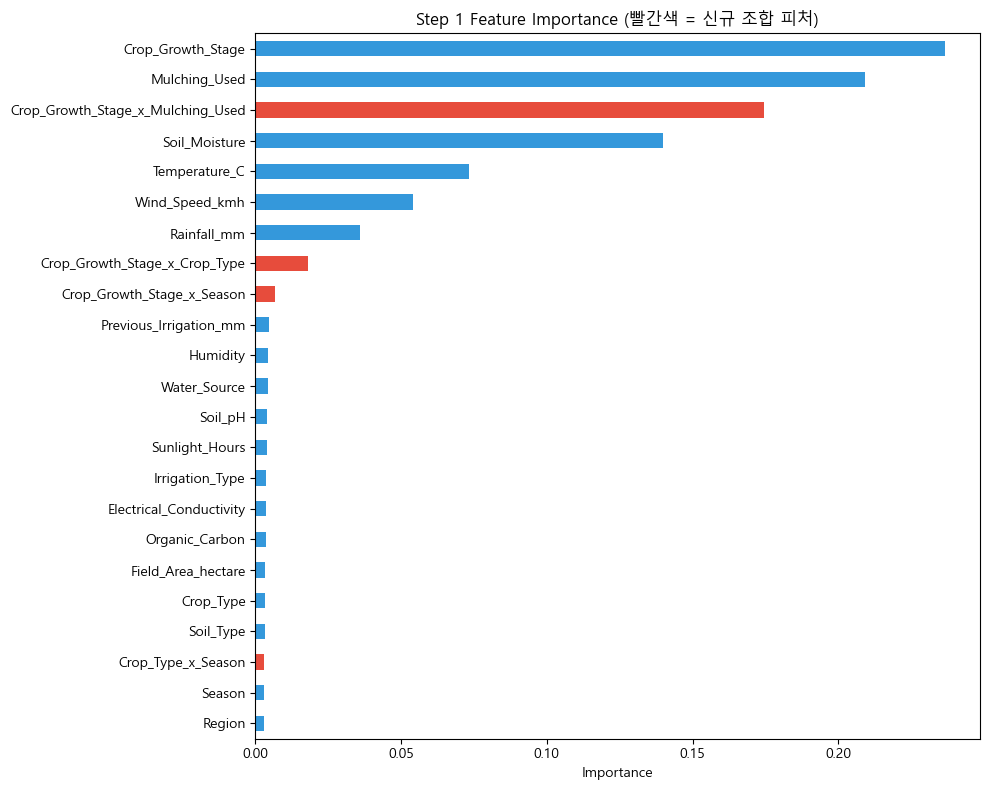


베이스라인 OOF: 0.96599
Step 1 OOF:    0.96591
변화량:        -0.00008


In [5]:
# Step 1 Feature Importance
fig, ax = plt.subplots(figsize=(10, 8))
importance = models_s1[-1].feature_importances_
feat_imp = pd.Series(importance, index=feature_cols).sort_values(ascending=True)
colors = ['#e74c3c' if c in tier1_cols else '#3498db' for c in feat_imp.index]
feat_imp.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Step 1 Feature Importance (빨간색 = 신규 조합 피처)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

# 베이스라인 대비 비교
baseline_oof = 0.96599
step1_oof = balanced_accuracy_score(y, oof_preds_s1.argmax(axis=1))
print(f"\n베이스라인 OOF: {baseline_oof:.5f}")
print(f"Step 1 OOF:    {step1_oof:.5f}")
print(f"변화량:        {step1_oof - baseline_oof:+.5f}")

## Step 2: Tier 2 조합 추가 (6개)

In [6]:
# 원본 데이터 다시 로드 (Step 1 인코딩이 적용되어 있으므로)
train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')

# Tier 1 + Tier 2 모두 적용
all_pairs = TIER1_PAIRS + TIER2_PAIRS
all_pair_cols = add_pairwise_features(train, all_pairs)
_ = add_pairwise_features(test, all_pairs)

# LabelEncoding
target_le = LabelEncoder()
y = target_le.fit_transform(train[TARGET])

all_cat_cols = CAT_COLS + all_pair_cols
label_encoders = {}
for col in all_cat_cols:
    le = LabelEncoder()
    combined = pd.concat([train[col], test[col]], ignore_index=True).astype(str)
    le.fit(combined)
    train[col] = le.transform(train[col].astype(str))
    test[col] = le.transform(test[col].astype(str))
    label_encoders[col] = le

drop_cols = ['id', TARGET]
feature_cols_s2 = [c for c in train.columns if c not in drop_cols]
X2 = train[feature_cols_s2]
X2_test = test[feature_cols_s2]

sample_weights = compute_sample_weight('balanced', y)

print(f"피처 수: {len(feature_cols_s2)} (베이스라인 19 → Step1 23 → Step2 {len(feature_cols_s2)})")
print(f"추가된 Tier 2 피처: {all_pair_cols[4:]}")

print("\n=== Step 2: Tier 1+2 조합 (10개) ===")
oof_preds_s2, test_preds_s2, scores_s2, models_s2 = train_and_evaluate(
    X2, y, X2_test, sample_weights, xgb_params)

피처 수: 29 (베이스라인 19 → Step1 23 → Step2 29)
추가된 Tier 2 피처: ['Soil_Type_x_Crop_Type', 'Soil_Type_x_Mulching_Used', 'Irrigation_Type_x_Water_Source', 'Irrigation_Type_x_Crop_Type', 'Region_x_Season', 'Region_x_Crop_Type']

=== Step 2: Tier 1+2 조합 (10개) ===
  Fold 0: 0.96483
  Fold 1: 0.96627
  Fold 2: 0.96693
  Fold 3: 0.96541
  Fold 4: 0.96500
  Overall OOF: 0.96569 (Mean: 0.96569 ± 0.00079)


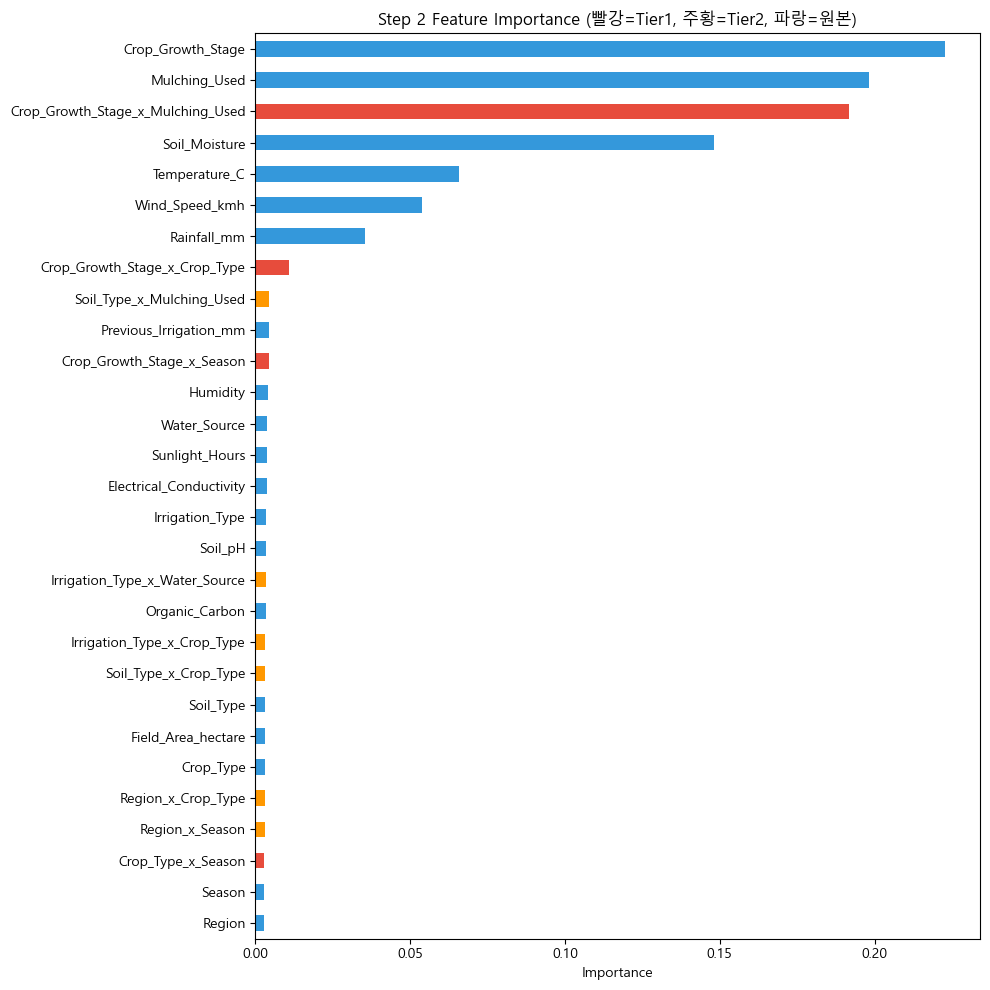


베이스라인 OOF: 0.96599
Step 1 OOF:    0.96591 (-0.00008)
Step 2 OOF:    0.96569 (-0.00030)
Step 1→2 변화: -0.00022


In [7]:
# Step 2 Feature Importance
fig, ax = plt.subplots(figsize=(10, 10))
importance = models_s2[-1].feature_importances_
feat_imp = pd.Series(importance, index=feature_cols_s2).sort_values(ascending=True)
tier2_cols = all_pair_cols[4:]
colors = ['#e74c3c' if c in tier1_cols else '#ff9800' if c in tier2_cols else '#3498db'
          for c in feat_imp.index]
feat_imp.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Step 2 Feature Importance (빨강=Tier1, 주황=Tier2, 파랑=원본)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

# 단계별 비교
step2_oof = balanced_accuracy_score(y, oof_preds_s2.argmax(axis=1))
print(f"\n{'='*50}")
print(f"베이스라인 OOF: {baseline_oof:.5f}")
print(f"Step 1 OOF:    {step1_oof:.5f} ({step1_oof - baseline_oof:+.5f})")
print(f"Step 2 OOF:    {step2_oof:.5f} ({step2_oof - baseline_oof:+.5f})")
print(f"Step 1→2 변화: {step2_oof - step1_oof:+.5f}")

## Step 3: TargetEncoder 적용

In [8]:
from sklearn.preprocessing import TargetEncoder

# 원본 데이터 다시 로드
train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')

# 페어와이즈 피처 생성 (Tier 1 + 2)
all_pair_cols = add_pairwise_features(train, TIER1_PAIRS + TIER2_PAIRS)
_ = add_pairwise_features(test, TIER1_PAIRS + TIER2_PAIRS)

# 타겟 인코딩
target_le = LabelEncoder()
y = target_le.fit_transform(train[TARGET])

# TargetEncoder 대상 = 원본 범주형 + 조합 피처
te_target_cols = CAT_COLS + all_pair_cols

# 일반 LabelEncoding도 유지 (TE와 함께 사용)
for col in te_target_cols:
    le = LabelEncoder()
    combined = pd.concat([train[col], test[col]], ignore_index=True).astype(str)
    le.fit(combined)
    train[col] = le.transform(train[col].astype(str))
    test[col] = le.transform(test[col].astype(str))

# CV-based TargetEncoding (누수 방지)
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
oof_preds_s3 = np.zeros((len(train), 3))
test_preds_s3 = np.zeros((len(test), 3))
fold_scores_s3 = []

drop_cols = ['id', TARGET]
base_feature_cols = [c for c in train.columns if c not in drop_cols]

for fold, (train_idx, val_idx) in enumerate(skf.split(train, y)):
    X_tr = train.iloc[train_idx].copy()
    X_val = train.iloc[val_idx].copy()
    X_te = test.copy()
    y_tr, y_val = y[train_idx], y[val_idx]

    # Fold 내에서 TargetEncoder fit (누수 방지)
    encoder = TargetEncoder(target_type='multiclass', cv=5, random_state=SEED, smooth='auto')
    te_tr = encoder.fit_transform(X_tr[te_target_cols], y_tr)
    te_val = encoder.transform(X_val[te_target_cols])
    te_te = encoder.transform(X_te[te_target_cols])

    # TE 피처 이름 생성 (클래스별 3개씩)
    te_feature_names = []
    for col in te_target_cols:
        for cls in range(3):
            te_feature_names.append(f"te_{col}_c{cls}")

    te_tr_df = pd.DataFrame(te_tr, columns=te_feature_names, index=X_tr.index)
    te_val_df = pd.DataFrame(te_val, columns=te_feature_names, index=X_val.index)
    te_te_df = pd.DataFrame(te_te, columns=te_feature_names, index=X_te.index)

    # 원본 피처 + TE 피처 결합
    X_tr_full = pd.concat([X_tr[base_feature_cols], te_tr_df], axis=1)
    X_val_full = pd.concat([X_val[base_feature_cols], te_val_df], axis=1)
    X_te_full = pd.concat([X_te[base_feature_cols], te_te_df], axis=1)

    sw_tr = compute_sample_weight('balanced', y_tr)

    model = XGBClassifier(**xgb_params)
    model.fit(X_tr_full, y_tr, sample_weight=sw_tr,
              eval_set=[(X_val_full, y_val)], verbose=0)

    oof_preds_s3[val_idx] = model.predict_proba(X_val_full)
    test_preds_s3 += model.predict_proba(X_te_full) / N_FOLDS

    score = balanced_accuracy_score(y_val, oof_preds_s3[val_idx].argmax(axis=1))
    fold_scores_s3.append(score)
    print(f"  Fold {fold}: {score:.5f}")

    if fold == N_FOLDS - 1:
        last_model_s3 = model
        last_feature_cols_s3 = list(X_tr_full.columns)

step3_oof = balanced_accuracy_score(y, oof_preds_s3.argmax(axis=1))
print(f"  Overall OOF: {step3_oof:.5f} (Mean: {np.mean(fold_scores_s3):.5f} ± {np.std(fold_scores_s3):.5f})")

  Fold 0: 0.96477
  Fold 1: 0.96638
  Fold 2: 0.96580
  Fold 3: 0.96439
  Fold 4: 0.96491
  Overall OOF: 0.96525 (Mean: 0.96525 ± 0.00073)


## 결과 비교 및 제출

In [9]:
# 단계별 결과 요약
results = {
    'Baseline (19 피처)': baseline_oof,
    'Step 1: +Tier1 (23 피처)': step1_oof,
    'Step 2: +Tier2 (29 피처)': step2_oof,
    'Step 3: +TargetEncoder': step3_oof,
}

print("=" * 55)
print(f"{'단계':<30} {'OOF':>8} {'변화량':>10}")
print("=" * 55)
for name, score in results.items():
    diff = score - baseline_oof
    print(f"{name:<30} {score:>8.5f} {diff:>+10.5f}")
print("=" * 55)

# 최고 점수 Step의 예측으로 제출
best_step = max(results, key=results.get)
print(f"\n최고 성능: {best_step} ({results[best_step]:.5f})")

단계                                  OOF        변화량
Baseline (19 피처)                0.96599   +0.00000
Step 1: +Tier1 (23 피처)          0.96591   -0.00008
Step 2: +Tier2 (29 피처)          0.96569   -0.00030
Step 3: +TargetEncoder          0.96525   -0.00074

최고 성능: Baseline (19 피처) (0.96599)


In [10]:
# 최고 성능 Step으로 제출 파일 생성
# Step 3이 최고면 test_preds_s3, Step 2면 test_preds_s2, Step 1이면 test_preds_s1
best_preds = {'Step 1': test_preds_s1, 'Step 2': test_preds_s2, 'Step 3': test_preds_s3}

# 각 Step별 제출 파일 생성 (비교 제출 가능)
for step_name, preds in [('s1_tier1', test_preds_s1), ('s2_tier12', test_preds_s2), ('s3_te', test_preds_s3)]:
    test_labels = preds.argmax(axis=1)
    test_label_names = target_le.inverse_transform(test_labels)
    submission = pd.DataFrame({'id': test['id'], 'Irrigation_Need': test_label_names})
    path = f'../submissions/submission_exp002_{step_name}.csv'
    submission.to_csv(path, index=False)
    print(f"저장: {path}")
    print(f"  분포: {dict(submission['Irrigation_Need'].value_counts())}\n")

저장: ../submissions/submission_exp002_s1_tier1.csv
  분포: {'Low': np.int64(159932), 'Medium': np.int64(101265), 'High': np.int64(8803)}

저장: ../submissions/submission_exp002_s2_tier12.csv
  분포: {'Low': np.int64(159949), 'Medium': np.int64(101251), 'High': np.int64(8800)}

저장: ../submissions/submission_exp002_s3_te.csv
  분포: {'Low': np.int64(159970), 'Medium': np.int64(101241), 'High': np.int64(8789)}

